In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Creating a dataframe for Learning Linear Regression

In [46]:
# ── Reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)
n = 100

# CGPA: uniformly spread between 5.5 and 9.5 (realistic NIT range)
cgpa = np.round(np.random.uniform(5.5, 9.5, n), 2)
noise = np.random.normal(loc=0, scale=0.5, size=n)
package = np.round(1.5 * cgpa + (-3.0) + noise, 2)

# Clip package to realistic range: 3 LPA to 12 LPA
package = np.clip(package, 3.0, 12.0)

# ── Build DataFrame ───────────────────────────────────────────────────────────
placement = pd.DataFrame({
    'cgpa': cgpa,
    'package_lpa': package
})


In [47]:
placement

,cgpa,package_lpa
0,7.00,7.54
1,9.30,10.80
2,8.43,9.69
3,7.89,7.84
4,6.12,6.07
...,...,...
95,7.48,7.81
96,7.59,8.35
97,7.21,7.99
98,5.60,5.54


In [48]:
# Seperate the x and y columns 
x = placement[['cgpa']]
y = placement['package_lpa']

In [52]:
print(x.shape)
y.shape

(100, 1)


(100,)

In [ ]:
# Form the training and testing data 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=2)

In [ ]:
# Making the model with name lr
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [ ]:
# Fit the model 
lr.fit(x_train,y_train)

LinearRegression()

In [15]:
print(x_test.head())
print(y_test.head())

    cgpa
83  5.75
30  7.93
56  5.85
24  7.32
16  6.72
83    5.95
30    9.84
56    5.24
24    7.27
16    6.73
Name: package_lpa, dtype: float64


In [ ]:
# Testing the points 
lr.predict(x_test.iloc[3].values.reshape(1,1))

c:\Users\Pradhuman\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([8.01196334])

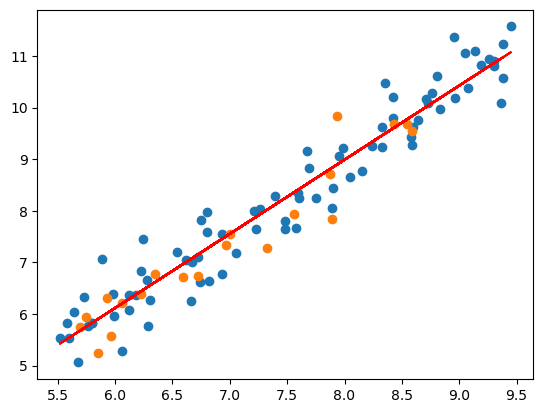

In [32]:
# Let us look at the scatter plot of x and y
plt.scatter(x_train,y_train) # Train points 
plt.scatter(x_test,y_test) # Test Points
plt.plot(x,lr.predict(x),color = 'red') # Linear Regression Model 

In [35]:
import seaborn as sns

In [33]:
# This was the slope of the linear regression model
m = lr.coef_
m

array([1.43668175])

In [34]:
# This gives us the y intercept of the linear regression model
b = lr.intercept_
b

np.float64(-2.504547072542616)

In [54]:
y_pred = lr.predict(x_test)

In [ ]:
# manual way to find MSE, MAE, RMSE, r2 score
MSE = (sum((y_test-y_pred)**2))/y_test.shape[0] # in square lpa
RMSE = np.sqrt(MSE) # in lpa
MAE = (sum(abs(y_test-y_pred)))/y_test.shape[0] # in lpa 
MAE
r2_score = 1 - (sum((y_test-y_pred)**2)/sum((y_test-y_test.mean())**2))
r2_score

0.9071126580364335

In [71]:
# using module
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

In [73]:
print("\n Final Testing Output Along With the Error")
final_df = pd.DataFrame({'cgpa':x_test['cgpa'].values,
                         'Actual Package(LPA)':y_test.values,
                         'Predicted Package':y_pred.round(2)})
print(f"\n {final_df}")


 Final Testing Output Along With the Error

     cgpa  Actual Package(LPA)  Predicted Package
0   5.75                 5.95               5.76
1   7.93                 9.84               8.89
2   5.85                 5.24               5.90
3   7.32                 7.27               8.01
4   6.72                 6.73               7.15
5   6.97                 7.34               7.51
6   8.43                 9.69               9.61
7   7.56                 7.94               8.36
8   7.87                 8.72               8.80
9   6.35                 6.78               6.62
10  5.93                 6.31               6.01
11  8.54                 9.69               9.76
12  8.59                 9.54               9.84
13  6.23                 6.39               6.45
14  7.00                 7.54               7.55
15  6.06                 6.22               6.20
16  7.89                 7.84               8.83
17  5.69                 5.74               5.67
18  6.59               

In [74]:
print(f'\n Output of using this Model MSE : {mse} \n MAE : {mae} \n R2 Score : {r2}')


 Output of using this Model MSE : 0.19031805926276155 
 MAE : 0.3207462874144359 
 R2 Score : 0.9071126580364335


In [ ]:
# R2 score is 90% which is great since the model can predict the variation in the package 
# upto 90% by just the input column